In [ ]:
# Downloading data and preparing the environment
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

def label_to_numpy(labels):
  final_labels = np.zeros((len(labels), 4))
  for i in range(len(labels)):
    label = labels[i]
    if label == 'Attentive':
      final_labels[i,:] = np.array([1, 0, 0, 0])
    if label == 'DrinkingCoffee':
      final_labels[i,:] = np.array([0, 1, 0, 0])
    if label == 'UsingMirror':
      final_labels[i,:] = np.array([0, 0, 1, 0])
    if label == 'UsingRadio':
      final_labels[i,:] = np.array([0, 0, 0, 1])
  return final_labels

class pkg:
  # Downloading and loading data
  def get_metadata(metadata_path, which_splits = ['train', 'test']):
    '''returns metadata dataframe which contains columns of:
       * index: index of data into numpy data
       * class: class of image
       * split: which dataset split is this a part of?
    '''
    metadata = pd.read_csv(metadata_path)
    keep_idx = metadata['split'].isin(which_splits)
    metadata = metadata[keep_idx]

    # Getting dataframes (training and testing) for each class
    df_coffee_train = metadata[(metadata['class'] == 'DrinkingCoffee') & \
                         (metadata['split'] == 'train')]
    df_coffee_test = metadata[(metadata['class'] == 'DrinkingCoffee') & \
                         (metadata['split'] == 'test')]
    df_mirror_train = metadata[(metadata['class'] == 'UsingMirror') & \
                         (metadata['split'] == 'train')]
    df_mirror_test = metadata[(metadata['class'] == 'UsingMirror') & \
                         (metadata['split'] == 'test')]
    df_attentive_train = metadata[(metadata['class'] == 'Attentive') & \
                         (metadata['split'] == 'train')]
    df_attentive_test = metadata[(metadata['class'] == 'Attentive') & \
                         (metadata['split'] == 'test')]
    df_radio_train = metadata[(metadata['class'] == 'UsingRadio') & \
                         (metadata['split'] == 'train')]
    df_radio_test = metadata[(metadata['class'] == 'UsingRadio') & \
                         (metadata['split'] == 'test')]

    # Geting the number of items in the class with the lowest number of images
    num_samples_train = min(df_coffee_train.shape[0], \
                            df_mirror_train.shape[0], \
                            df_attentive_train.shape[0], \
                            df_radio_train.shape[0])
    num_samples_test = min(df_coffee_test.shape[0], \
                            df_mirror_test.shape[0], \
                            df_attentive_test.shape[0], \
                            df_radio_test.shape[0])

    # Resampling each of the classes and concatenating the images
    metadata_train = pd.concat([df_coffee_train.sample(num_samples_train), \
                          df_mirror_train.sample(num_samples_train), \
                          df_attentive_train.sample(num_samples_train), \
                          df_radio_train.sample(num_samples_train) ])
    metadata_test = pd.concat([df_coffee_test.sample(num_samples_test), \
                          df_mirror_test.sample(num_samples_test), \
                          df_attentive_test.sample(num_samples_test), \
                          df_radio_test.sample(num_samples_test) ])

    metadata = pd.concat( [metadata_train, metadata_test] )

    return metadata

  def get_data_split(split_name, flatten, all_data, metadata, image_shape):
    '''
    returns images (data), labels from folder of format [image_folder]/[split_name]/[class_name]/
    flattens if flatten option is True
    '''
    # Geting dataframes for each class
    df_coffee_train = metadata[(metadata['class'] == 'DrinkingCoffee') & \
                         (metadata['split'] == 'train')]
    df_coffee_test = metadata[(metadata['class'] == 'DrinkingCoffee') & \
                         (metadata['split'] == 'test')]
    df_mirror_train = metadata[(metadata['class'] == 'UsingMirror') & \
                         (metadata['split'] == 'train')]
    df_mirror_test = metadata[(metadata['class'] == 'UsingMirror') & \
                         (metadata['split'] == 'test')]
    df_attentive_train = metadata[(metadata['class'] == 'Attentive') & \
                         (metadata['split'] == 'train')]
    df_attentive_test = metadata[(metadata['class'] == 'Attentive') & \
                         (metadata['split'] == 'test')]
    df_radio_train = metadata[(metadata['class'] == 'UsingRadio') & \
                         (metadata['split'] == 'train')]
    df_radio_test = metadata[(metadata['class'] == 'UsingRadio') & \
                         (metadata['split'] == 'test')]

    # Geting number of items in class with lowest number of images
    num_samples_train = min(df_coffee_train.shape[0], \
                            df_mirror_train.shape[0], \
                            df_attentive_train.shape[0], \
                            df_radio_train.shape[0])
    num_samples_test = min(df_coffee_test.shape[0], \
                            df_mirror_test.shape[0], \
                            df_attentive_test.shape[0], \
                            df_radio_test.shape[0])

    # Resampling each of the classes and concatenating the images
    metadata_train = pd.concat([df_coffee_train.sample(num_samples_train), \
                          df_mirror_train.sample(num_samples_train), \
                          df_attentive_train.sample(num_samples_train), \
                          df_radio_train.sample(num_samples_train) ])
    metadata_test = pd.concat([df_coffee_test.sample(num_samples_test), \
                          df_mirror_test.sample(num_samples_test), \
                          df_attentive_test.sample(num_samples_test), \
                          df_radio_test.sample(num_samples_test) ])

    metadata = pd.concat( [metadata_train, metadata_test] )

    sub_df = metadata[metadata['split'].isin([split_name])]
    index  = sub_df['index'].values
    labels = sub_df['class'].values
    data = all_data[index,:]
    if flatten:
      data = data.reshape([-1, np.prod(image_shape)])
    return data, labels

  def get_train_data(flatten, all_data, metadata, image_shape):
    return get_data_split('train', flatten, all_data, metadata, image_shape)

  def get_test_data(flatten, all_data, metadata, image_shape):
    return get_data_split('test', flatten, all_data, metadata, image_shape)

  def get_field_data(flatten, all_data, metadata, image_shape):
    return get_data_split('field', flatten, all_data, metadata, image_shape)

class helpers:
  # Plotting
  def plot_one_image(data, label_str, index = None, image_shape = [64,64,3]):
    '''
    if data is a single image, display that image

    if data is a 4d stack of images, display that image
    '''

    labels = [label_str]
    num_dims   = len(data.shape)
    num_labels = len(labels)
    target_shape = (64,64,3)
    # reshape data if necessary
    if num_dims == 1:
      data = data.reshape(target_shape)
    if num_dims == 2:
      data = data.reshape(np.vstack[-1, image_shape])
    num_dims   = len(data.shape)

    # check if single or multiple images
    if num_dims == 3:
      if num_labels > 1:
        print('Multiple labels does not make sense for single image.')
        return

      label = labels
      if num_labels == 0:
        label = ''
      image = data

    if num_dims == 4:
      image = data[index, :]
      label = labels[index]

    # plot image of interest
    print('Label: %s'%label)
    plt.imshow(image)
    plt.show()

  def plot_acc(history, ax = None, xlabel = 'Epoch #'):
    history = history.history
    history.update({'epoch':list(range(len(history['val_acc'])))})
    history = pd.DataFrame.from_dict(history)

    best_epoch = history.sort_values(by = 'val_acc', ascending = False).iloc[0]['epoch']

    if not ax:
      f, ax = plt.subplots(1,1)
    sns.lineplot(x = 'epoch', y = 'val_acc', data = history, label = 'Validation', ax = ax)
    sns.lineplot(x = 'epoch', y = 'acc', data = history, label = 'Training', ax = ax)
    ax.axhline(0.25, linestyle = '--',color='red', label = 'Chance')
    ax.axvline(x = best_epoch, linestyle = '--', color = 'green', label = 'Best Epoch')
    ax.legend(loc = 1)
    ax.set_ylim([0.4, 1])

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Accuracy (Fraction)')

    plt.show()

image_data_path      = './image_data.npy'
metadata_path        = './metadata.csv'
image_shape          = (64, 64, 3)

###
!wget -q --show-progress 'https://storage.googleapis.com/inspirit-ai-data-bucket-1/Data/AI%20Scholars/Sessions%206%20-%2010%20(Projects)/Project%20-%20Driver%20Distraction%20Detection/metadata.csv'
!wget -q --show-progress 'https://storage.googleapis.com/inspirit-ai-data-bucket-1/Data/AI%20Scholars/Sessions%206%20-%2010%20(Projects)/Project%20-%20Driver%20Distraction%20Detection/image_data.npy'

# Pre-loading all data of interest
_all_data = np.load(image_data_path)
_metadata = pkg.get_metadata(metadata_path, ['train','test','field'])

# Preparing definitions, downloading and loading data
get_data_split = pkg.get_data_split
get_metadata    = lambda :                 pkg.get_metadata(metadata_path, ['train','test'])
get_train_data  = lambda flatten = False : pkg.get_train_data(flatten = flatten, all_data = _all_data, metadata = _metadata, image_shape = image_shape)
get_test_data   = lambda flatten = False : pkg.get_test_data(flatten = flatten, all_data = _all_data, metadata = _metadata, image_shape = image_shape)
get_field_data  = lambda flatten = False : pkg.get_field_data(flatten = flatten, all_data = _all_data, metadata = _metadata, image_shape = image_shape)

# Plotting
plot_one_image = lambda data, labels, index = None: helpers.plot_one_image(data = data, label_str = labels, index = index, image_shape = image_shape);
plot_acc       = lambda history: helpers.plot_acc(history)

metadata.csv        100%[===================>] 200.33K  --.-KB/s    in 0.01s   
image_data.npy      100%[===================>] 423.61M   132MB/s    in 3.3s    


In [ ]:
# Getting a table with information about all of the images
metadata = pkg.get_metadata(metadata_path)

print(metadata.head())
print(metadata.tail())
# class is the category of how attentive the drive is
# split tells whether the image has been put in the training or testing set
# index is the ID of the image

               class  split  index
1109  DrinkingCoffee  train   1109
5452  DrinkingCoffee  train   5452
4492  DrinkingCoffee  train   4492
3873  DrinkingCoffee  train   3873
1043  DrinkingCoffee  train   1043
           class split  index
7855  UsingRadio  test   7855
8386  UsingRadio  test   8386
8615  UsingRadio  test   8615
8797  UsingRadio  test   8797
8981  UsingRadio  test   8981


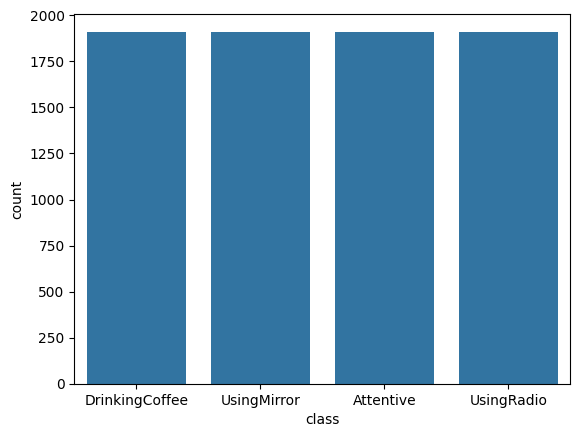

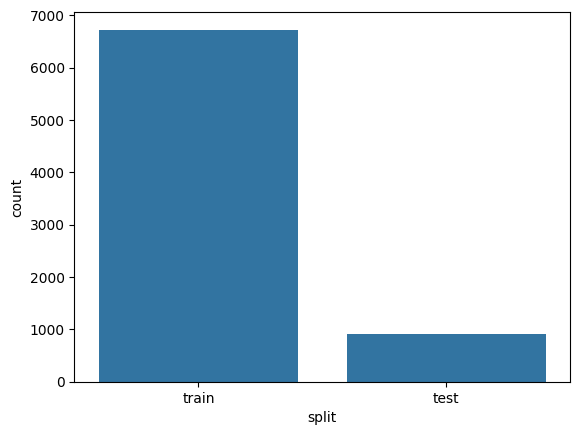

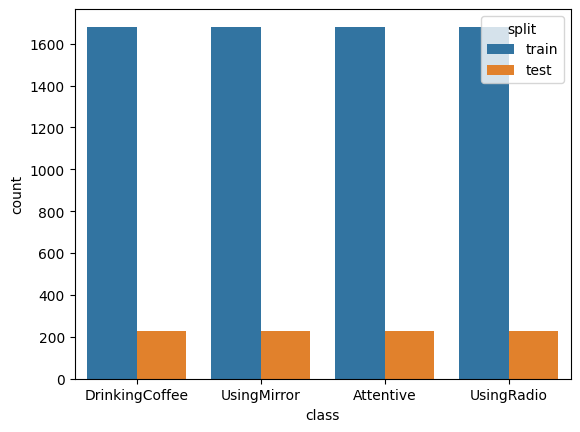

In [ ]:
# visualizing the total number of images
sns.countplot(x = 'class', data = metadata)
plt.show()

# visualizing the ratio for split in data
sns.countplot(x = 'split', data = metadata)
plt.show()

#visualizing how the split ration affects the number of images in each class
sns.countplot(x = 'class', data = metadata, hue = 'split')
plt.show()

In [ ]:
# loads the entire training set
X_train, y_train = get_train_data()

# gets the first image in the train_data array
image = X_train[0,:]

# gets the first label in the train_labels array
image_label = y_train[0]

image = image.reshape(64, 64, 3)

print('Our image is stored as %s in Python'%type(image))

# dimension_0 represents the image height
# dimension_1 represents the image width
# dimension_2 stands for the 3 colors (r, g, b)
print('Our image has dimensions of (%d, %d, %d)'%image.shape)
print('Our image has label %s'%image_label)

Our image is stored as <class 'numpy.ndarray'> in Python
Our image has dimensions of (64, 64, 3)
Our image has label DrinkingCoffee


Label: [['UsingRadio']]


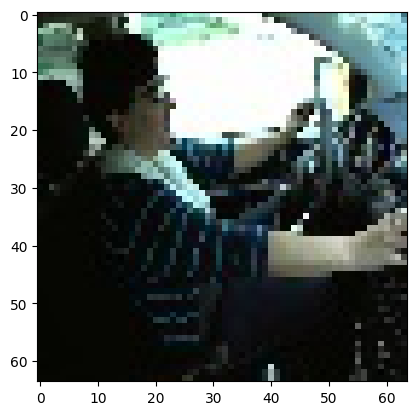

None
Label: [['UsingRadio']]


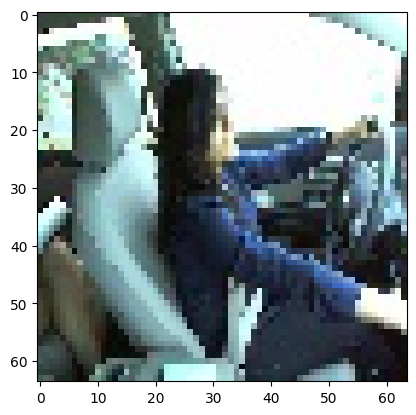

None
Label: [['UsingRadio']]


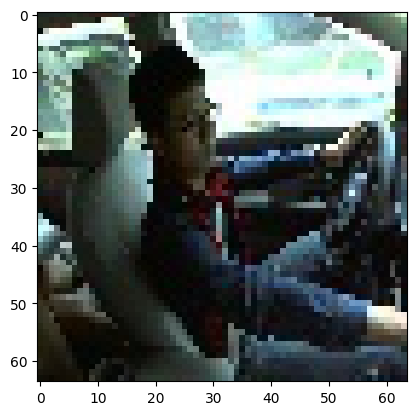

None
Label: [['Attentive']]


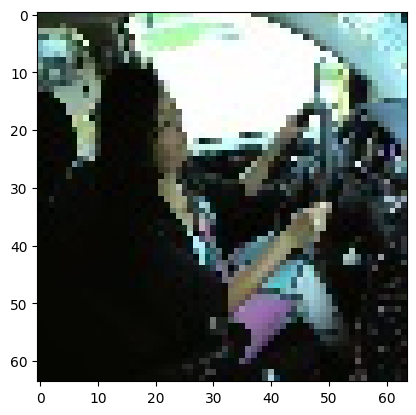

None
Label: [['Attentive']]


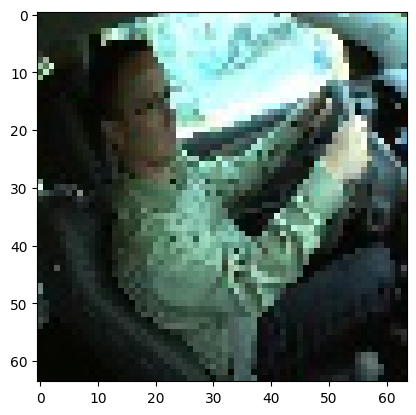

None
Label: [['Attentive']]


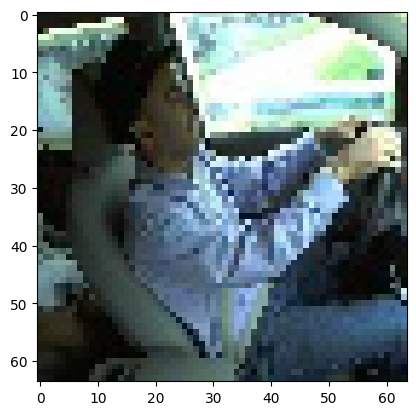

None
Label: [['DrinkingCoffee']]


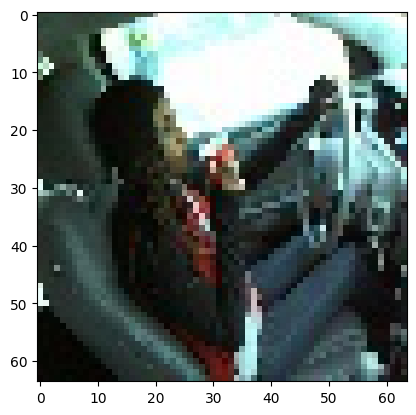

Label: [['DrinkingCoffee']]


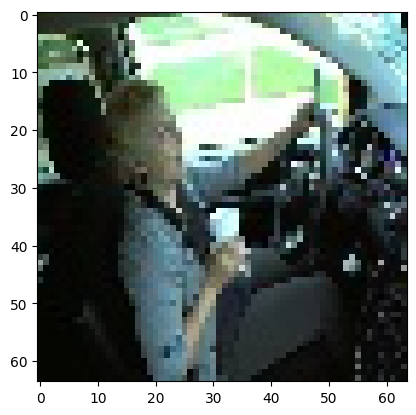

Label: [['DrinkingCoffee']]


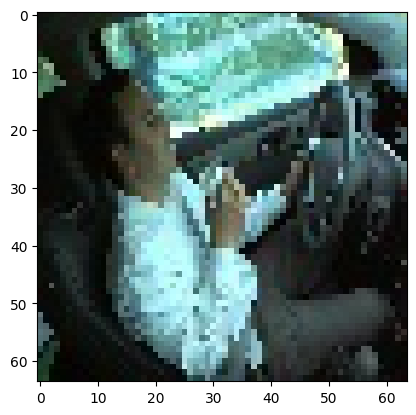

Label: [['UsingMirror']]


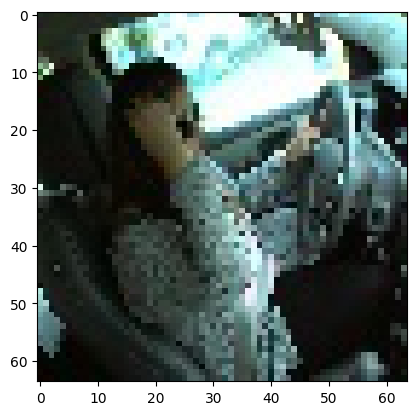

Label: [['UsingMirror']]


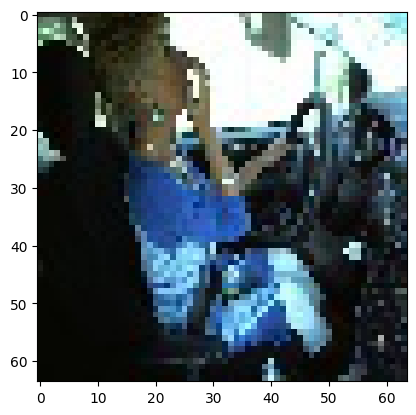

Label: [['UsingMirror']]


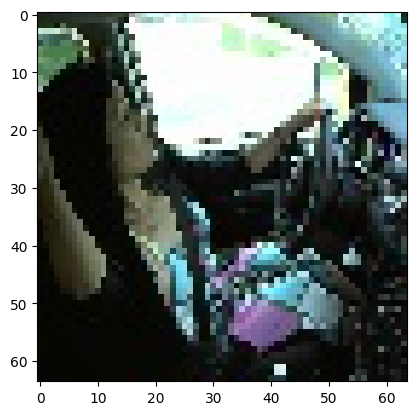

In [ ]:
# grab all images whose corresponding label is 'UsingRadio'
radio_X_train = X_train[y_train=='UsingRadio']
attentive_X_train = X_train[y_train=='Attentive']
coffee_X_train = X_train[y_train=='DrinkingCoffee']
mirror_X_train = X_train[y_train=='UsingMirror']

# Using a for loop to visualize UsingRadio images
for i in range(3):
  image_ID = i
  image = radio_X_train[image_ID,:]
  image_label = 'UsingRadio'
  print(plot_one_image(image, labels=[image_label]))

# Using a for loop to visualize Attentive images
for i in range(3):
  image_ID = i
  image = attentive_X_train[image_ID,:]
  image_label = 'Attentive'
  print(plot_one_image(image, labels=[image_label]))

  # Using a for loop to visualize DrinkingCoffee images
for i in range(3):
  image_ID = i
  image = coffee_X_train[image_ID,:]
  image_label = 'DrinkingCoffee'
  plot_one_image(image, labels=[image_label])

  # Using a for loop to visualize UsingMirror images
for i in range(3):
  image_ID = i
  image = mirror_X_train[image_ID,:]
  image_label = 'UsingMirror'
  plot_one_image(image, labels=[image_label])

Label: [['UsingMirror']]


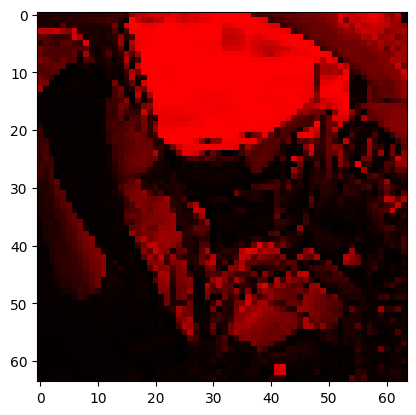

None


In [ ]:
# making a copy of the image to manipulate its properties
new_image = np.copy(image)

# remove green value
new_image[:, :, 1] = 0

# remove blue value
new_image[:, :, 2] = 0

print(plot_one_image(new_image, labels=[image_label]))

In [ ]:
# the machine learning model inputs are images
# outputs are either UsingRadio, UsingMirror, DrinkingCoffee, or Attentive
# the problem being solved is classification

# Getting the data and flattening it
(X_train, y_train) = get_train_data(flatten=True)
(X_test, y_test) = get_test_data(flatten=True)

# defining the model (with parameters), fitting the model with the train data and labels,
# predicting on the test data, and then printing the accuracy_score

# understanding the accuracy of KNearestNeighbors when predicting one class of images
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)
accuracy_1 = accuracy_score(y_test, y_pred)
print(accuracy_1*100)

50.43478260869565


In [ ]:
# Additional model with Decision Tree
dt = DecisionTreeClassifier(max_depth = 5)
dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)
accuracy_2 = accuracy_score(y_test, y_pred)
print(accuracy_2*100)

NameError: name 'X_test' is not defined